# Testing Classification on Sphere vs Ellipsoid to see how much stretching is needed to differentiate.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ecc_vr as vr 

from Sphere_Ellipsoid_Utils import unif_hypersphere, unif_hyperellipsoid, unit_ball_volume, scale_axes_target_volume, edge_count_curve, simulate_curves

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# What the function below does...

This function `sphere_vs_ellipsoid_edge_curve_classifier` simulates points clouds from a sphere and an ellipsoid, converts each point cloud into an edge count curve over a grid of threshold values `t`, train a logistic-regression classifierto distinguish the two shapes from those curves, and returns the fitted model plus summary results.



In [5]:
def sphere_vs_ellipsoid_edge_curve_classifier(
        n_points: int = 100,
        t_grid: np.ndarray | None = None,
        n_resamples: int = 300,
        ambient_dim: int | None = None,
        ellipsoid_stretch: np.ndarray | list | tuple | None = None,
        target_volume: float = 1.0,
        seed1: int = 42,
        seed2: int = 43,
        test_size: float = 0.25,
        random_state: int = 0,
):  
    
    if t_grid is None:
        t_grid = np.linspace(0.5, 5, 30)
    else:
        t_grid = np.asarray(t_grid, dtype = float)

    if ellipsoid_stretch is None:
        ambient_dim = 3 if ambient_dim is None else ambient_dim
        ellipsoid_stretch = np.ones(ambient_dim, dtype = float)
        ellipsoid_stretch[0] = 1.5
    else:
        ellipsoid_stretch = np.asarray(ellipsoid_stretch, dtype = float)
        if ambient_dim is None:
            ambient_dim = ellipsoid_stretch.size
            raise ValueError("ambient_dim must match len(ellipsoid_stretch).")
    
    target_volume = unit_ball_volume(ambient_dim) * np.prod(ellipsoid_stretch)
    
    sphere_radius = (target_volume / unit_ball_volume(ambient_dim)) ** ( 1.0 / ambient_dim)
    ellipsoid_axes = scale_axes_target_volume(ellipsoid_stretch, target_volume)

    curves_sphere = simulate_curves(
        point_cloud_sampler = lambda s: unif_hypersphere(
            n_points = n_points,
            d = ambient_dim,
            r = sphere_radius,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        seed = seed1,
    )
    
    curves_ellipsoid = simulate_curves(
        point_cloud_sampler=lambda s: unif_hyperellipsoid(
            n_points,
            *ellipsoid_axes,
            seed = s,
        ),
        n_resamples=n_resamples,
        t_grid=t_grid,
        seed=seed2,
    )

    X = np.vstack([curves_sphere, curves_ellipsoid])
    y = np.array([0] * len(curves_sphere) + [1] * len(curves_ellipsoid))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size = test_size,
        random_state=random_state,
        stratify=y
    )

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter = 5000),
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    return {
        "shape1": "sphere",
        "shape2": "ellipsoid",
        "ambient_dim": ambient_dim,
        "target_volume": target_volume,
        "sphere_radius": sphere_radius,
        "ellipsoid_stretch_input": np.asarray(ellipsoid_stretch, dtype = float),
        "ellipsoid_axes": ellipsoid_axes,
        "t_grid": t_grid,
        "curves1": curves_sphere,
        "curves2": curves_ellipsoid,
        "curves_sphere": curves_sphere,
        "curves_ellipsoid": curves_ellipsoid,
        "classifier": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "report": classification_report(
            y_test,
            y_pred,
            target_names=["Sphere", "Ellipsoid"],
            zero_division=0,
        ),
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
    }

In [8]:
def plot_sphere_ellipsoid_results(result):
    t_grid = result["t_grid"]
    curves_sphere = result["curves_sphere"]
    curves_ellipsoid = result["curves_ellipsoid"]

    mean1 = curves_sphere.mean(axis=0)
    sd1 = curves_sphere.std(axis = 0, ddof = 1)

    mean2 = curves_ellipsoid.mean(axis = 0)
    sd2 = curves_ellipsoid.std(axis =0, ddof = 1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

    ax[0].plot(t_grid, mean1, lw = 2, label = "Sphere Edge Count Simulation Mean")
    ax[0].fill_between(t_grid, mean1 - sd1, mean1 + sd1, alpha = 0.2)

    ax[0].plot(t_grid, mean2, lw = 2, label = "Ellipsoid Edge Count Simulation Mean")
    ax[0].fill_between(t_grid, mean2 - sd2, mean2 + sd2, alpha = 0.2)

    ax[0].set_xlabel("t")
    ax[0].set_ylabel("Edge Count")
    ax[0].set_title("Edge Count Curves")
    ax[0].legend()

    ConfusionMatrixDisplay.from_predictions(
        result["y_test"],
        result["y_pred"],
        display_labels=["Sphere", "Ellipsoid"],
        cmap = "Blues",
        ax=ax[1],
    )
    ax[1].set_title("Classifier Confusion Matrix")

    plt.tight_layout()
    plt.show()

    print("Accuracy:", result["accuracy"])
    print(result["report"])

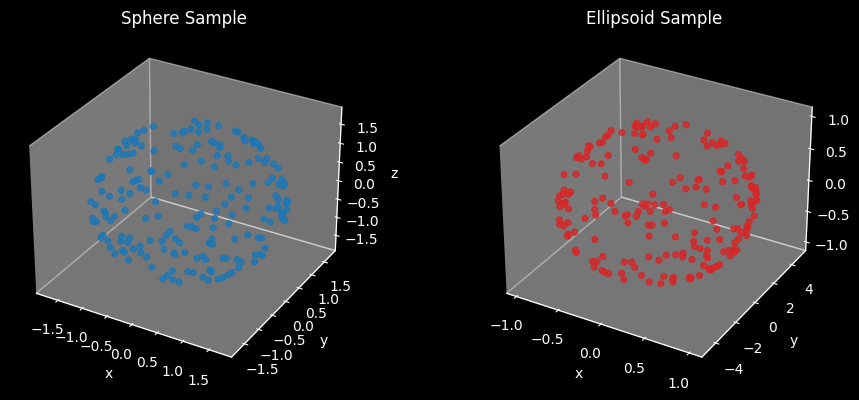

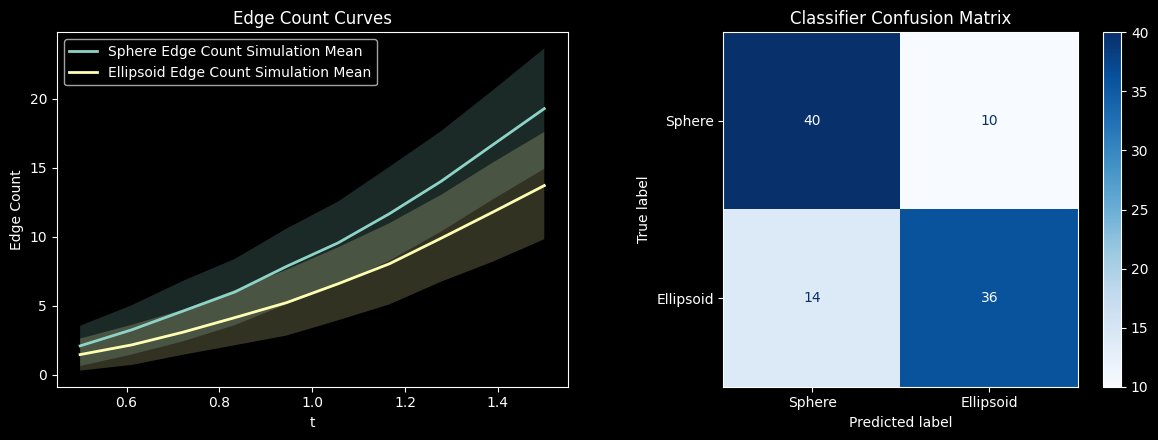

Accuracy: 0.76
              precision    recall  f1-score   support

      Sphere       0.74      0.80      0.77        50
   Ellipsoid       0.78      0.72      0.75        50

    accuracy                           0.76       100
   macro avg       0.76      0.76      0.76       100
weighted avg       0.76      0.76      0.76       100



In [14]:
plt.style.use("dark_background")

# INPUT
n_points = 200
n_resamples = 200
ambient_dim = 3
t_grid = np.linspace(0.5,1.5, 10)
ellipsoid_stretch = [1.0, 5.0, 1.0]

result = sphere_vs_ellipsoid_edge_curve_classifier(
    ambient_dim=ambient_dim,
    n_points=n_points,
    n_resamples=n_resamples,
    t_grid=t_grid,
    ellipsoid_stretch=ellipsoid_stretch,
)

fig = plt.figure(figsize=(10, 4))

samples = [
    ("Sphere", unif_hypersphere(n_points, result["ambient_dim"], r = result["sphere_radius"], seed = 123), "tab:blue"),
    ("Ellipsoid", unif_hyperellipsoid(n_points, result["ellipsoid_axes"], seed = 456), "tab:red"),
]

for i, (shape, X, color) in enumerate(samples, start = 1):
    projected = X.shape[1] > 3
    if projected:
        X = vr.pca_project(X, out_dim = 2)
    
    d = X.shape[1]
    ax = fig.add_subplot(1, 2, i, projection="3d" if d == 3 else None)

    if d == 3:
        ax.scatter(X[:, 0], X[:, 1], X[:, 2], s = 18, alpha = 0.8, color=color)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
    elif d == 2:
        ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.8, color=color)
        #ax.set_aspect("equal")
        ax.set_xlabel("PC1" if projected else "x")
        ax.set_ylabel("PC2" if projected else "y")
    else:
        ax.scatter(X[:, 0], np.zeros(len(X)), s=18, alpha=0.8, color=color)
        ax.set_xlabel("x")
        ax.set_ylabel("")

    ax.set_title(f"{shape} Sample")
    ax.grid(False)

plt.tight_layout()
plt.show()

plot_sphere_ellipsoid_results(result)
